# Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from Partitioner import getDefaultWineSets
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')

seed = 1234
np.random.seed(seed)  

c:\Users\laure\OneDrive\Documents\2025 college\178\178 Group Project\Partitioner.py:103: SyntaxWarning: invalid escape sequence '\w'
  red_wine_data = pd.read_csv("wine+quality\winequality-red.csv", delimiter=";")
c:\Users\laure\OneDrive\Documents\2025 college\178\178 Group Project\Partitioner.py:104: SyntaxWarning: invalid escape sequence '\w'
  white_wine_data = pd.read_csv("wine+quality\winequality-white.csv", delimiter=";")


# Load splits

In [3]:
# get shared group split
X_train, X_val, X_test, y_train, y_val, y_test = getDefaultWineSets()

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (3897, 12)
Validation shape: (1300, 12)
Test shape: (1300, 12)


# standard scaler 

In [4]:
# scale using training data only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")

Scaling done.


# Hyper Parameter searching (standard scale)

In [5]:
import pandas as pd
best_model = None
best_val_acc = 0
best_params = None

hidden_layer_options = [
    (50,), (100,), (100, 50), (128, 64), (128, 64, 32)
]
alpha_options = [0.0001, 0.001, 0.01]
lr_options = [0.001, 0.01]
results = []

for hidden_layers in hidden_layer_options:
    for alpha in alpha_options:
        for lr in lr_options:
            model = MLPClassifier(
                hidden_layer_sizes=hidden_layers,
                activation='relu',
                solver='adam',
                alpha=alpha,
                learning_rate_init=lr,
                early_stopping=True,
                max_iter=100,
                random_state=seed,
                n_iter_no_change=15
            )

            model.fit(X_train_scaled, y_train)

            # Validate
            val_pred = model.predict(X_val_scaled)
            val_acc = accuracy_score(y_val, val_pred)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = model
                best_params = (hidden_layers, alpha, lr)

            results.append({
                "Hidden Layers": hidden_layers,
                "Alpha": alpha,
                "Learning Rate": lr,
                "Validation Accuracy": val_acc
            })

# -----------------------------
# Step 3: Evaluate best model
# -----------------------------
train_pred = best_model.predict(X_train_scaled)
test_pred = best_model.predict(X_test_scaled)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

# Error rates
train_error = 1 - train_acc
test_error = 1 - test_acc

# -----------------------------
# Results
# -----------------------------
print("Best Hyperparameters:")
print(f"Hidden Layers: {best_params[0]}")
print(f"Alpha: {best_params[1]}")
print(f"Learning Rate: {best_params[2]}")

print("\nPerformance:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

print("\nError Rates:")
print(f"Training Error: {train_error:.4f}")
print(f"Test Error: {test_error:.4f}")

results_df = pd.DataFrame(results)

# Sort by best validation accuracy
results_df = results_df.sort_values(by="Validation Accuracy", ascending=False)

print(results_df)

Best Hyperparameters:
Hidden Layers: (100,)
Alpha: 0.0001
Learning Rate: 0.01

Performance:
Training Accuracy: 0.5905
Validation Accuracy: 0.5815
Test Accuracy: 0.5592

Error Rates:
Training Error: 0.4095
Test Error: 0.4408
    Hidden Layers   Alpha  Learning Rate  Validation Accuracy
7          (100,)  0.0001          0.010             0.581538
9          (100,)  0.0010          0.010             0.578462
24  (128, 64, 32)  0.0001          0.001             0.573846
15      (100, 50)  0.0010          0.010             0.573846
18      (128, 64)  0.0001          0.001             0.573077
28  (128, 64, 32)  0.0100          0.001             0.571538
13      (100, 50)  0.0001          0.010             0.570769
20      (128, 64)  0.0010          0.001             0.570769
29  (128, 64, 32)  0.0100          0.010             0.568462
11         (100,)  0.0100          0.010             0.566923
1           (50,)  0.0001          0.010             0.566154
26  (128, 64, 32)  0.0010       

Text(0.5, 1.0, 'Neural Network Confusion Matrix')

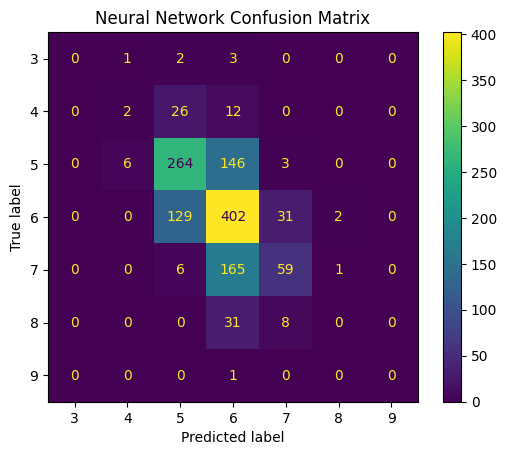

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, test_pred)
plt.title("Neural Network Confusion Matrix")


# Hyperparameter tuning (gridcv)

In [8]:
# -----------------------------
# Step 2: Define model + grid
# -----------------------------
mlp = MLPClassifier(
    max_iter=100, 
    random_state=seed,
    early_stopping=True,
    n_iter_no_change=15
    )

param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (100, 50), (128, 64), (128, 64, 32)],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "activation": ["relu"],
    "solver": ["adam"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# -----------------------------
# Step 3: GridSearchCV (ONLY on training data)
# -----------------------------
grid = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=cv,                # 5-fold cross-validation
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

# -----------------------------
# Step 4: Best model
# -----------------------------
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

# -----------------------------
# Step 5: Evaluate on validation set
# -----------------------------
val_acc = accuracy_score(y_val, best_model.predict(X_val_scaled))
print("Validation Accuracy:", val_acc)

# -----------------------------
# Step 6: Final test evaluation
# -----------------------------
test_acc = accuracy_score(y_test, best_model.predict(X_test_scaled))
print("Test Accuracy:", test_acc)

Best Parameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.01, 'solver': 'adam'}
Best CV Accuracy: 0.5653052894901418
Validation Accuracy: 0.5615384615384615
Test Accuracy: 0.5515384615384615
